In [6]:
import numpy as np
from pprint import pprint
from matplotlib import pyplot as plt

# KickerControl

**[04-11-2024]:** Here's an update of the Kicker Control scripts I've been working on for beam steering. In the future, the logical flow of the module may change due to integration with Karabo and DOOCS. I've tried to preempt those changes and will explain some of the design considerations.

The `kickercontrol` package is designed to enable photon beam steering at the European XFEL. It provides the necessary tools to facilitate the operation of beam steering instrumentation at the European XFEL on the inter-train and intra-train timescales. An overview of the core structure of the package is presented below:

<div align="center">

![kickerControl Package Structure](./img/kickercontrol_IO.png)

</div>

**[04-11-2024]:** At the moment, the device sits completely separate from Karabo as a matter of priorities. The `DACSignalGenerator` and `Scan` method have thus far been designed with the intent to interface with the `Karabo` scene.

## `KickerDevice()`

[``device.py``](../kickercontrol/device.py) is a simple `pydoocs` interface to the KL kickers located in the XTL. Each `KickerDevice` has the ability to read and write the DAC channel of a physical kicker device. Each DAC channel takes a 16-bit signed integer, which corresponds to a ±1V input signal. The input signal yields a proportional kicker current. The strength of the kicker current varies between kickers, as does the signal duration and interval. The table of suitable kickers, their direction, and their current (proportional to kick strength) are listed below:

<div align="center">

**Table 1: Kicker Devices for Photon Beam Steering.** Each kicker is named with respect to its physical location. The maximum gradient of the signal is limited by the kicker rise time of 20 A/µs. Amplitude stability is proportional to kick strength: ~ 3e-04 dA/A.

| Kicker   | Notes                   | Current      |
|----------|-------------------------|--------------|
| KMX1938  | Horizontal Compensation | ± 300 A      |
| KNY1938  | Vertical Compensation   | ± 50 A       |
| KMX1965  | Horizontal Compensation | ± 300 A      |
| KNY1965  | Vertical Compensation   | ± 50 A       |
| KL2005   | Vertical Kick           | ± 15 A       |

</div>

Each `KickerDevice` initialises a kicker DAC channel for read/write.

### Reading a `KickerDevice`

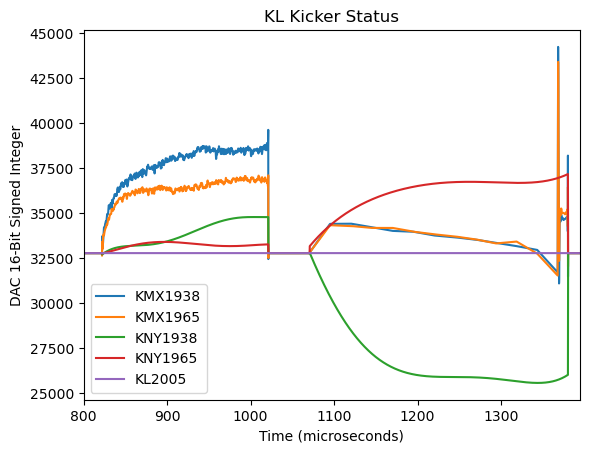

In [2]:
from kickercontrol.device import (KMX1938, KMX1965, KNY1938,
                                  KNY1965,KL2005)

kicker_devices = [KMX1938, KMX1965, KNY1938,
                  KNY1965, KL2005]

fig, ax = plt.subplots(1,1)

ax.set_xlabel("Time (microseconds)")
ax.set_ylabel("DAC 16-Bit Signed Integer")
ax.set_title("KL Kicker Status")

ax.set_xlim(800, 800+2700*220e-03)

for kicker in kicker_devices:
    
    k = kicker()
    time, signal = k.read_dac().T

    ax.plot(time, signal, label = k.__name__)

_ = ax.legend()
plt.show()



### Writing a `KickerDevice`

**[04-11-2024]:** We don't have permission to write that signal to the kicker - and maybe for good reason. For now, this function will only be possible from xfel-oper desktop nodes. In the future, the `write_dac()` function will be modified to interface w/ `Karabo Bridge`

In [3]:
from kickercontrol.device import (KMX1938, KMX1965, KNY1938,
                                  KNY1965,KL2005)

kicker_devices = [KMX1938, KMX1965, KNY1938,
                  KNY1965, KL2005]

### All signals have length 65535 - however their intervals change
signal_length = 65535

for kicker in kicker_devices:
    
    k = kicker()

    print(f"DAC interval: {k.get_signal_interval} ns")

    ### Generate an arbitrary signal
    signal = np.random.rand(signal_length)
    try:
        k.write_dac(signal)
    except Exception as e:
        pass

    break


DAC interval: 0.11076757201543068 ns
Failed to write DAC: {'code': 102, 'message': 'RPC: Authentication error'}


## `DAQSignalGenerator()`

The [``signal.py``](../kickercontrol/signal.py) module generates arbitrary signals that are suitable to be written to a specified `KickerDevice`. `DACSignalGenerator` takes a `KickerDevice` as its input, and requires that a beamline be specified using its [bunch pattern identifier](https://accelconf.web.cern.ch/fel2019/papers/wep008.pdf). By specifying a `beamline` we can **assert** that the start and end times of the signal are within the bounds of the specified beam region for that beamline. Upon initialising these classes, the `DACSignalGenerator` generates a signal of duration equal to:

<div align="center">

```python
signal_duration = KickerDevice().get_signal_interval*65535
```
</div>

The `DACSignalGenerator` class was written with the intent of supporting a `Karabo` device in future. In addition to specifying a `KickerDevice` and `beamline`, the `DACSignalGenerator` takes as its inputs a supported `oscillator` and `**kwargs**` corresponding to the oscillator variables. The oscillators, along with instructions on adding more oscillators in the future are located in [``__base__.py``](../kickercontrol/__base__.py).

Each `oscillator` in `__base__.py` generates a signal of length equal to the above `signal_duration`. Only values in the range spanning the beam-region of the corresponding beamline can be written to the KickerDevice.

In [7]:
from kickercontrol.signal import DACSignalGenerator

dac_generator = DACSignalGenerator(KL2005(), beamline = None )
pprint(dac_generator.__base__)

{'cos': <class 'kickercontrol.__base__.CosSignal'>,
 'custom': <class 'kickercontrol.__base__.CustomExpressionSignal'>,
 'exponential_decay': <class 'kickercontrol.__base__.ExponentialDecaySignal'>,
 'gaussian': <class 'kickercontrol.__base__.GaussianSignal'>,
 'line': <class 'kickercontrol.__base__.LineSignal'>,
 'ramp': <class 'kickercontrol.__base__.RampSignal'>,
 'sin': <class 'kickercontrol.__base__.SinSignal'>,
 'spiral_cos': <class 'kickercontrol.__base__.SpiralScanCosSignal'>,
 'spiral_sin': <class 'kickercontrol.__base__.SpiralScanSinSignal'>,
 'square': <class 'kickercontrol.__base__.SquareSignal'>,
 'step_with_decay': <class 'kickercontrol.__base__.StepWithDecaySignal'>,
 'triangle': <class 'kickercontrol.__base__.TriangleSignal'>}


### Using Custom Expressions

## `MiniScan()`


## User Interface
`main.py` is the intended user interface of the `kickercontrol` module

### `Scan()`

In [5]:
from kickercontrol import SignalGenerator

## Preset Scans and Functions

## **[WIP]** Optimisation